# Project 1: Co-Creative Curation Pipeline on MovieLens 100K
**Course:** Artificial Intelligence for Entertainment

## 1. Setup and Global Configuration
> "Your notebook must include a FAST MODE flag (or similar) that trains with small settings and runs end-to-end in under ~10 minutes." *(Section 6)*

In this initial section, we initialize the imports, download the data and centralize all hyperparameters to avoid "magic numbers" scattered throughout the code.

In [ ]:
import os, zipfile, urllib.request, json
from pathlib import Path
import numpy as np
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt

# ==========================================
# GLOBAL CONFIGURATION & EXECUTION MODE
# ==========================================

FAST_MODE = True

# --- Data Settings ---
RANDOM_SEED = 42
TRAIN_SPLIT_RATIO = 0.8
DATA_DIR = Path("data_movielens_100k")
URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"

# --- Hyperparameters: Matrix Factorization ---
MF_DIM_NORMAL = 20
MF_DIM_FAST = 10
MF_LAMBDA = 0.05

# --- Hyperparameters: SGD ---
SGD_EPOCHS_NORMAL = 10
SGD_EPOCHS_FAST = 3
SGD_ETA = 0.01

# --- Hyperparameters: ALS ---
ALS_ITERS_NORMAL = 10
ALS_ITERS_FAST = 4

# --- Hyperparameters: Pairwise LTR ---
PW_EPOCHS_NORMAL = 5
PW_EPOCHS_FAST = 2
PW_LR = 0.01
PW_REG = 0.01

# --- Hyperparameters: MMR and EMA Sessions ---
CANDIDATE_POOL_SIZE = 80    # M: Top-M candidates from base ranker
SLATE_SIZE = 10             # K: Final recommendation slate size
MMR_ALPHA_DEFAULT = 0.4     # Diversity vs Relevance trade-off
EMA_RHO = 0.3               # User profile update rate
SESSION_ROUNDS = 5          # Number of rounds in interactive simulation


# ==========================================
# DATA DOWNLOAD
# ==========================================

print(f"Configurations loaded. [FAST_MODE = {FAST_MODE}]")
DATA_DIR.mkdir(parents=True, exist_ok=True)
zip_path = DATA_DIR / "ml-100k.zip"

if not zip_path.exists():
    print("Downloading MovieLens 100K...")
    urllib.request.urlretrieve(URL, zip_path.as_posix())
else:
    print("MovieLens 100K already downloaded:", zip_path)

# Unzip
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(DATA_DIR)

print("Extracted to:", DATA_DIR)
print("Top-level contents:", list(DATA_DIR.iterdir())[:5])

Configurations loaded. [FAST_MODE = True]
Extracted to: data_movielens_100k
Top-level contents: [WindowsPath('data_movielens_100k/ml-100k'), WindowsPath('data_movielens_100k/ml-100k.zip')]


## 2. Data Processing (Train/Test Split)
> "Use an 80/20 random split over observed ratings." *(Section 2.1)*

Here we load the `u.data` dataset, map the IDs to contiguous indices (required for matrix operations), and randomly split the dataset into training and testing sets.

> Load ratings (u.data)

In [ ]:
ratings_path = DATA_DIR / "ml-100k" / "u.data"
# u.data format: user_id \t item_id \t rating \t timestamp

ratings = pd.read_csv(
    ratings_path,
    sep = "\t",
    header = None,
    names = ["user_id", "item_id", "rating", "timestamp"]
)

ratings.head(), ratings.shape

(   user_id  item_id  rating  timestamp
 0      196      242       3  881250949
 1      186      302       3  891717742
 2       22      377       1  878887116
 3      244       51       2  880606923
 4      166      346       1  886397596,
 (100000, 4))

> Map raw IDs to contiguous indices

In [ ]:
# Create contiguous indices for users and items
user_ids = ratings["user_id"].unique()
item_ids = ratings["item_id"].unique()

user2idx = {u: i for i, u in enumerate(sorted(user_ids))}
item2idx = {m: i for i, m in enumerate(sorted(item_ids))}

ratings["u"] = ratings["user_id"].map(user2idx).astype(int)
ratings["i"] = ratings["item_id"].map(item2idx).astype(int)

n_users = len(user2idx)
n_items = len(item2idx)

print("n_users:", n_users, "n_items:", n_items)
ratings[["u","i","rating"]].head()

n_users: 943 n_items: 1682


,u,i,rating
0,195,241,3
1,185,301,3
2,21,376,1
3,243,50,2
4,165,345,1


> Train/test split (random 80/20 over observed ratings)

In [ ]:
rng = np.random.default_rng(RANDOM_SEED)
idx = np.arange(len(ratings))
rng.shuffle(idx)

split_point = int(TRAIN_SPLIT_RATIO * len(idx))
train = ratings.iloc[idx[:split_point]].reset_index(drop=True)
test  = ratings.iloc[idx[split_point:]].reset_index(drop=True)

# Convert to numpy arrays for fast loops
train_u = train["u"].to_numpy(np.int64)
train_i = train["i"].to_numpy(np.int64)
train_r = train["rating"].to_numpy(np.float32)

test_u = test["u"].to_numpy(np.int64)
test_i = test["i"].to_numpy(np.int64)
test_r = test["rating"].to_numpy(np.float32)

mu = train_r.mean()

print(f"Dataset partitioned: {len(train)} train | {len(test)} test.")

Dataset partitioned: 80000 train | 20000 test.


## 3. Candidate Generation
> "C(u) = {all movies not rated by user u in the train split}." *(Section 1.2)*

We generate lists of valid items for recommendation, ensuring no *Data Leakage* occurs by utilizing highly efficient Hash Table lookups.

In [ ]:
# ==========================================
# CANDIDATE GENERATOR
# ==========================================

# Pre-compute training history for O(1) lookup times
train_history_dict = train.groupby('user_id')['item_id'].apply(set).to_dict()


def get_seen_movies(user_id):
    """Returns the set of movies seen in training in constant time."""
    return train_history_dict.get(user_id, set())


def generate_candidates(user):
    """Generates eligible candidates (items never seen in training)."""
    all_movies = set(item2idx.keys())
    seen_movies = get_seen_movies(user)
    return list(all_movies - seen_movies)

In [ ]:
# ==========================================
# DEMONSTRATION: CANDIDATE GENERATION
# ==========================================
# This is a quick demonstration of the generator in action for a random user.

demo_user = random.choice(list(train['user_id'].unique()))
demo_candidates = generate_candidates(demo_user)
demo_m_limit = 100

print(f"User ID: {demo_user}")
print(f"Total eligible candidates generated: {len(demo_candidates)}")
print(f"Truncating to top M={demo_m_limit} for ranker input...")
demo_top_m = demo_candidates[:demo_m_limit]
print(f"Sample of candidates to be ranked: {demo_top_m[:10]}...")

User ID: 78
Total eligible candidates generated: 1661
Truncating to top M=100 for ranker input...
Sample of candidates to be ranked: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]...


## 4. Base Rankers (Popularity & Matrix Factorization)
> "Implement Matrix Factorization (MF) with SGD and ALS and Learning-to-Rank via pairwise preference learning." *(Section 1.3)*

In this section, we initialize the latent factors and optimize the required base models.

In [ ]:
# ==========================================
# 4.1. POPULARITY BASELINE
# ==========================================

def popularity_ranker(train_df):
    return (
        train_df.groupby("item_id").size()
        .reset_index(name="interaction_count")
        .sort_values(by="interaction_count", ascending=False)
    )


popularity_df = popularity_ranker(train)
print("Popularity Baseline calculated.")

Popularity Baseline calculated.


In [ ]:
# ==========================================
# 4.2. MF INITIALIZATION
# ==========================================

d = MF_DIM_FAST if FAST_MODE else MF_DIM_NORMAL
lam = MF_LAMBDA

P = 0.1 * rng.standard_normal((n_users, d)).astype(np.float32)
Q = 0.1 * rng.standard_normal((n_items, d)).astype(np.float32)
bu = np.zeros(n_users, dtype=np.float32)
bi = np.zeros(n_items, dtype=np.float32)

print(f"Latent matrices initialized with dimension d={d}.")


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))


def predict(u, i, mu, bu, bi, P, Q):
    return mu + bu[u] + bi[i] + float(P[u] @ Q[i])


def batch_predict(u_arr, i_arr, mu, bu, bi, P, Q):
    out = np.empty(len(u_arr), dtype=np.float32)
    for k, (u, i) in enumerate(zip(u_arr, i_arr)):
        out[k] = mu + bu[u] + bi[i] + float(P[u] @ Q[i])
    return out

Latent matrices initialized with dimension d=10.


In [ ]:
# ==========================================
# 4.3. MATRIX FACTORIZATION: SGD
# ==========================================

epochs_sgd = SGD_EPOCHS_FAST if FAST_MODE else SGD_EPOCHS_NORMAL
eta = SGD_ETA
sgd_test_rmse = []

print(f"Training MF-SGD for {epochs_sgd} epochs...")

for ep in range(1, epochs_sgd + 1):
    # Shuffle training examples
    order = np.arange(len(train_u))
    rng.shuffle(order)

    for idx in order:
        u = train_u[idx]
        i = train_i[idx]
        r = train_r[idx]

        # prediction + error
        rhat = mu + bu[u] + bi[i] + float(P[u] @ Q[i])
        err = r - rhat

        # Corrected SGD updates
        bu[u] = bu[u] + eta * (err - lam * bu[u])
        bi[i] = bi[i] + eta * (err - lam * bi[i])
        P[u] = P[u] + eta * (err * Q[i] - lam * P[u])
        Q[i] = Q[i] + eta * (err * P[u] - lam * Q[i])

    # Track RMSE each epoch
    tr_rmse = rmse(train_r, batch_predict(train_u, train_i, mu, bu, bi, P, Q))
    te_rmse = rmse(test_r, batch_predict(test_u, test_i, mu, bu, bi, P, Q))
    sgd_test_rmse.append(te_rmse)
    print(f"Epoch {ep:02d} | train RMSE={tr_rmse:.4f} | test RMSE={te_rmse:.4f}")


def rank_sgd(u_raw, items_raw, mu, bu, bi, P, Q, user2idx, item2idx):
    if u_raw not in user2idx:
        return []

    u = user2idx[u_raw]
    scores = []

    for i_raw in items_raw:
        if i_raw not in item2idx:
            continue

        i = item2idx[i_raw]
        score = mu + bu[u] + bi[i] + P[u] @ Q[i]
        scores.append((i_raw, score))

    return [i for i, _ in sorted(scores, key=lambda x: -x[1])]

Training MF-SGD for 3 epochs...
Epoch 01 | train RMSE=0.9639 | test RMSE=0.9846
Epoch 02 | train RMSE=0.9390 | test RMSE=0.9669
Epoch 03 | train RMSE=0.9277 | test RMSE=0.9594


In [ ]:
# ==========================================
# 4.4. MATRIX FACTORIZATION: ALS
# ==========================================

iters_als = ALS_ITERS_FAST if FAST_MODE else ALS_ITERS_NORMAL

# For ALS we want fast access to items rated by a user and users who rated an item
user_ratings = defaultdict(list)  # u -> list of (i, r)
item_ratings = defaultdict(list)  # i -> list of (u, r)

for u, i, r in zip(train_u, train_i, train_r):
    user_ratings[int(u)].append((int(i), float(r)))
    item_ratings[int(i)].append((int(u), float(r)))

# Initialize P, Q, bu, bi for ALS
P_als = 0.1 * rng.standard_normal((n_users, d)).astype(np.float32)
Q_als = 0.1 * rng.standard_normal((n_items, d)).astype(np.float32)
bu_als = np.zeros(n_users, dtype=np.float32)
bi_als = np.zeros(n_items, dtype=np.float32)
# Precompute identity
I = np.eye(d + 1, dtype=np.float32)

als_test_rmse = [] # não está a ser usado para nada mas podemos usar para um grafico

print(f"Training MF-ALS for {iters_als} iterations...")

for iteration in range(iters_als):
    for u_idx in range(n_users):
        user_data = user_ratings.get(u_idx, [])
        if not user_data:
            continue

        item_indices = np.array([item for item, _ in user_data], dtype=np.int64)
        ratings_for_user = np.array([rating for _, rating in user_data], dtype=np.float32)

        # Target variable for ridge regression: r'_ui = r_ui - mu - b_i
        r_prime = ratings_for_user - mu - bi_als[item_indices]

        # Feature matrix for ridge regression: X_u = [1 | Q_items]
        Q_for_user = Q_als[item_indices] # Item factors for items rated by this user
        ones_col = np.ones((len(item_indices), 1), dtype=np.float32)
        X_u = np.hstack((ones_col, Q_for_user)) # Shape: (num_ratings_by_user, d+1)

        # Solve for w_u = [b_u, p_u^T]^T using (X_u^T X_u + lambda I)^-1 X_u^T r_prime
        XtX_plus_lambdaI = X_u.T @ X_u + lam * I

        try:
            w_u = np.linalg.solve(XtX_plus_lambdaI, X_u.T @ r_prime)
            bu_als[u_idx] = w_u[0] # First element is the user bias
            P_als[u_idx] = w_u[1:]  # Remaining elements are the user factors
        except np.linalg.LinAlgError:
            print("Inversion Error")
            continue


    # --- Update item factors Q and item biases bi ---
    # For each item i: solve for w_i = [b_i, q_i^T]^T using ridge regression
    for i_idx in range(n_items):
        item_data = item_ratings.get(i_idx, [])
        if not item_data:
            continue

        user_indices = np.array([user for user, _ in item_data], dtype=np.int64)
        ratings_for_item = np.array([rating for _, rating in item_data], dtype=np.float32)

        # Target variable for ridge regression: r''_ui = r_ui - mu - b_u
        r_double_prime = ratings_for_item - mu - bu_als[user_indices]

        # Feature matrix for ridge regression: X_i = [1 | P_users]
        P_for_item = P_als[user_indices] # User factors for users who rated this item
        ones_col = np.ones((len(user_indices), 1), dtype=np.float32)
        X_i = np.hstack((ones_col, P_for_item)) # Shape: (num_ratings_for_item, d+1)

        # Solve for w_i = [b_i, q_i^T]^T using (X_i^T X_i + lambda I)^-1 X_i^T r_double_prime
        XtX_plus_lambdaI = X_i.T @ X_i + lam * I

        try:
            w_i = np.linalg.solve(XtX_plus_lambdaI, X_i.T @ r_double_prime)
            bi_als[i_idx] = w_i[0] # First element is the item bias
            Q_als[i_idx] = w_i[1:]  # Remaining elements are the item factors
        except np.linalg.LinAlgError:
            print("Inversion Error")
            continue

    # Evaluate RMSE after each iteration using the updated _als parameters
    tr_rmse = rmse(train_r, batch_predict(train_u, train_i, mu, bu_als, bi_als, P_als, Q_als))
    te_rmse = rmse(test_r, batch_predict(test_u, test_i, mu, bu_als, bi_als, P_als, Q_als))
    als_test_rmse.append(te_rmse)
    print(f"ALS iter {iteration+1:02d} | train RMSE={tr_rmse:.4f} | test RMSE={te_rmse:.4f}")



# Define a ranking function for ALS
def rank_als(u_raw, items_raw, mu, bu, bi, P, Q, user2idx, item2idx):
    """
    Ranks items for a given user using the trained ALS model.

    Args:
        u_raw (int): The raw user ID.
        items_raw (list): A list of raw item IDs to rank.
        mu (float): Global mean rating.
        bu (np.ndarray): User bias vector.
        bi (np.ndarray): Item bias vector.
        P (np.ndarray): User factor matrix.
        Q (np.ndarray): Item factor matrix.
        user2idx (dict): Mapping from raw user ID to contiguous index.
        item2idx (dict): Mapping from raw item ID to contiguous index.

    Returns:
        list: A list of raw item IDs, sorted by predicted score in descending order.
    """
    if u_raw not in user2idx:
        return []

    u = user2idx[u_raw]
    scores = []

    for i_raw in items_raw:
        # Skip items not found in our item index mapping
        if i_raw not in item2idx:
            continue

        i = item2idx[i_raw]
        predicted_score = mu + bu[u] + bi[i] + P[u] @ Q[i]
        scores.append((i_raw, predicted_score))

    # Sort items by predicted score in descending order
    return [item for item, _ in sorted(scores, key=lambda x: x[1], reverse=True)]

Training MF-ALS for 4 iterations...
ALS iter 01 | train RMSE=0.7892 | test RMSE=1.1796
ALS iter 02 | train RMSE=0.7253 | test RMSE=1.2117
ALS iter 03 | train RMSE=0.6976 | test RMSE=1.2285
ALS iter 04 | train RMSE=0.6810 | test RMSE=1.2388


In [ ]:
# ==========================================
# 4.5. PAIRWISE LTR
# ==========================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


idx2user = {idx: u for u, idx in user2idx.items()}
idx2item = {idx: i for i, idx in item2idx.items()}

user_pos_items = defaultdict(list)
user_neg_items = defaultdict(list)

for _, row in train.iterrows():
    u = row["user_id"]
    i = row["item_id"]
    r = row["rating"]
    if r >= 4:
        user_pos_items[u].append(i)
    else:
        user_neg_items[u].append(i)

global_mean = train["rating"].mean()
user_bias = train.groupby("user_id")["rating"].mean().to_dict()
item_bias = train.groupby("item_id")["rating"].mean().to_dict()

pop_dict = popularity_df.set_index("item_id")["interaction_count"].to_dict()
max_pop = popularity_df["interaction_count"].max()


def build_feature(u, i):
    u_idx = user2idx[u]
    i_idx = item2idx[i]
    s_mf = predict(u_idx, i_idx, mu, bu, bi, P, Q)
    pop = pop_dict.get(i, 0) / max_pop
    return np.array([s_mf, bu[u_idx], bi[i_idx], pop, 1.0], dtype=np.float32)

user_item_features = defaultdict(dict)

for u in train["user_id"].unique():
    items = train["item_id"].unique()
    for i in items:
        user_item_features[u][i] = build_feature(u, i)

class PairwiseRanker:
    def __init__(self, dim, lr=0.01, reg=0.01, epochs=5):
        self.phi = np.zeros(dim)
        self.lr = lr
        self.reg = reg
        self.epochs = epochs


    def score(self, f_ui):
        return np.dot(self.phi, f_ui)


    def fit(self, user_item_features, user_pos_items, user_neg_items):
        for epoch in range(self.epochs):
            for u in user_pos_items:
                pos_items = user_pos_items[u]
                neg_items = user_neg_items[u]

                if len(pos_items) == 0 or len(neg_items) == 0:
                    continue

                i_pos = np.random.choice(pos_items)
                i_neg = np.random.choice(neg_items)

                f_pos = user_item_features[u][i_pos]
                f_neg = user_item_features[u][i_neg]

                delta_f = f_pos - f_neg
                x = np.dot(self.phi, delta_f)
                prob = sigmoid(x)

                grad = (prob - 1) * delta_f + self.reg * self.phi
                self.phi -= self.lr * grad

            print(f"Pairwise LTR Epoch {epoch+1} concluída.")


    def rank(self, user, candidate_items, user_item_features, top_k=10):
        scores = []
        for i in candidate_items:
            f_ui = user_item_features.get(user, {}).get(i)
            if f_ui is None:
                continue
            s = self.score(f_ui)
            scores.append((i, s))

        scores.sort(key=lambda x: x[1], reverse=True)
        return [i for i, _ in scores[:top_k]]



pw_epochs = PW_EPOCHS_FAST if FAST_MODE else PW_EPOCHS_NORMAL
ranker = PairwiseRanker(dim=5, lr=PW_LR, reg=PW_REG, epochs=pw_epochs)

print(f"Training Pairwise LTR for {pw_epochs} epochs...")
ranker.fit(user_item_features, user_pos_items, user_neg_items)

Training Pairwise LTR for 2 epochs...
Pairwise LTR Epoch 1 concluída.
Pairwise LTR Epoch 2 concluída.


## 5. MMR Reranking
> "MMR reranking over the top-M candidates to control diversity. Use genre vectors from u.item." *(Section 1.4)*

We normalize the genre vectors and apply the Maximal Marginal Relevance calculation.

In [ ]:
# ==========================================
# RERANKING (MAXIMAL MARGINAL RELEVANCE)
# ==========================================

item_columns = [
    'movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url',
    # --- These are the 19 binary genre columns ---
    'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

item_path = DATA_DIR / "ml-100k" / "u.item"

movies = pd.read_csv(
    item_path,
    sep='|',
    names=item_columns,
    encoding='latin-1'
)

# Normalization of every movie's vector

item_genres_normalized = {}
genre_cols = item_columns[5:]

for _,row in movies.iterrows():
    m_id = row['movie_id']
    genre_vec = row[genre_cols].to_numpy(dtype=float)
    magnitude = np.linalg.norm(genre_vec)

    if magnitude > 0: item_genres_normalized[m_id] = genre_vec/magnitude
    else: item_genres_normalized[m_id] = genre_vec #Fallback for edge cases (all zeros)

print(f"Loaded {len(item_genres_normalized)} normalized genre vectors")


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    # Since vectors are already normalized, cosine similarity is simply given by the dot product
    return float(np.dot(a,b))


def mmr_rerank(candidate_items, base_scores, item_features, K=10, alpha=0.4):
    """
    Reranks candidates using Maximal Marginal Relevance.

    :param candidate_items: List of candidate movie IDs (e.g., top M=80 from MF)
    :param base_scores: Dictionary mapping {movie_id: predicted_MF_score}
    :param item_features: Dictionary mapping {movie_id: normalized_genre_vector}
    :param K: The number of items to select for the final slate
    :param alpha: The diversity trade-off parameter
    :return: List of K selected movie IDs
    """


    # Since we're now working with scalars (ratings in range [1-5]), we have to normalize them so
    # they don't overpower the rest of the normal equation (the cosine_sim of the genre vectors and the alpha)

    scores_array = np.array([base_scores[c] for c in candidate_items])
    min_score, max_score = scores_array.min(), scores_array.max()

    scaled_scores = {}

    for c in candidate_items:
        if max_score > min_score:
            scaled_scores[c] = (base_scores[c] - min_score) / (max_score - min_score)
        else:
            scaled_scores[c] = 0.5 # Fallback for when the ratings are literally  all the same

    # Now the normal mmr can be done

    selected = []
    remaining = list(candidate_items)

    for step in range(min(K, len(candidate_items))):
        best_item = None
        best_mmr_score = -float('inf')
        best_relevancia = 0
        best_penalizacao = 0

        for c in remaining:
            relevance = scaled_scores[c]

            if len(selected) == 0:
                diversity_penality = 0.0
            else:
                c_vec = item_features[c]
                similarities = [cosine_sim(c_vec, item_features[s]) for s in selected]
                diversity_penality = max(similarities)

            mmr_score = (1-alpha) * relevance - alpha * diversity_penality

            if mmr_score > best_mmr_score:
                best_mmr_score = mmr_score
                best_item = c
                best_relevancia = relevance
                best_penalizacao = diversity_penality

        selected.append(best_item)
        remaining.remove(best_item)

    return selected

print("MMR Reranker initialized.")

Loaded 1682 normalized genre vectors
MMR Reranker initialized.


## 6. Temporal Personalization (Sessions and EMA)
> "Show at least 3 user sessions with 5 rounds each: recommend a slate -> choose one item -> update user's representation." *(Section 1.5)*

We simulate the passage of time. In each round, the user's latent vector is updated towards the chosen item's vector using Exponential Moving Average.

In [ ]:
# ==========================================
# INTERACTIVE SESSIONS & EMA UPDATE
# ==========================================

def ema_update(u_t, v_i, rho):
    """Updates the user state vector using EMA and re-normalizes."""
    updated_vec = (1 - rho) * u_t + rho * v_i
    norm = np.linalg.norm(updated_vec)
    return updated_vec / norm if norm > 0 else updated_vec


def simulate_user_session(user_raw_id, P, Q, bu, bi, mu, movies_df, rho=0.3, rounds=5, M=80, mmr=1):
    """Simulates interaction and updates latent representation across rounds."""
    if user_raw_id not in user2idx: return []

    u_idx = user2idx[user_raw_id]
    current_u_vec = P[u_idx].copy()
    seen_in_train = get_seen_movies(user_raw_id)
    session_history = set()

    print(f"\n=======================================================")
    print(f" SESSION START: User {user_raw_id} | rho rate = {rho}")
    print(f"=======================================================")

    for r in range(1, rounds + 1):
        candidates = [i for i in item2idx.keys() if i not in session_history and i not in seen_in_train]
        base_scores = {i: float(mu + bu[u_idx] + bi[item2idx[i]] + np.dot(current_u_vec, Q[item2idx[i]])) for i in candidates}

        top_m = sorted(candidates, key=lambda x: base_scores[x], reverse=True)[:M]
        if mmr == 1:
            slate = mmr_rerank(top_m, base_scores, item_genres_normalized, K=SLATE_SIZE, alpha=MMR_ALPHA_DEFAULT)
        else:
            slate = top_m
        print(f"\n--- Round {r} ---")
        print("Top 3 Recommendations from Slate:")
        for idx, m_id in enumerate(slate[:3], 1):
            title = movies_df.loc[movies_df['movie_id'] == m_id, 'title'].values[0]
            print(f"  {idx}. {title} (Base Score: {base_scores[m_id]:.2f})")

        chosen_item = random.choice(slate[:3])
        chosen_title = movies_df.loc[movies_df['movie_id'] == chosen_item, 'title'].values[0]
        print(f"  >> The user chose: {chosen_title}")

        session_history.add(chosen_item)
        current_u_vec = ema_update(current_u_vec, Q[item2idx[chosen_item]], rho)

        # logging sessões
        session_log = {
            "user_id": int(user_raw_id),
            "method": "session_round",
            "round": r,
            "slate": [int(x) for x in slate],
            "chosen_item": int(chosen_item),
            "updated_state_norm": float(np.linalg.norm(current_u_vec)) # State summary
        }
        with open("evaluation_logs.jsonl", 'a') as f:
            f.write(json.dumps(session_log) + '\n')

    return slate


# --- Run Simulations ---
test_users = [220, 15, 42]
for u in test_users:
    simulate_user_session(u, P_als, Q_als, bu_als, bi_als, mu, movies, rho=EMA_RHO, rounds=SESSION_ROUNDS, M=CANDIDATE_POOL_SIZE)


 SESSION START: User 220 | rho rate = 0.3

--- Round 1 ---
Top 3 Recommendations from Slate:
  1. Low Down Dirty Shame, A (1994) (Base Score: 11.02)
  2. One Night Stand (1997) (Base Score: 10.70)
  3. Three Caballeros, The (1945) (Base Score: 10.19)
  >> The user chose: Three Caballeros, The (1945)

--- Round 2 ---
Top 3 Recommendations from Slate:
  1. Love in the Afternoon (1957) (Base Score: 5.28)
  2. Wild Things (1998) (Base Score: 5.26)
  3. Far From Home: The Adventures of Yellow Dog (1995) (Base Score: 5.17)
  >> The user chose: Wild Things (1998)

--- Round 3 ---
Top 3 Recommendations from Slate:
  1. Geronimo: An American Legend (1993) (Base Score: 5.38)
  2. Living in Oblivion (1995) (Base Score: 5.12)
  3. Ghost in the Shell (Kokaku kidotai) (1995) (Base Score: 4.99)
  >> The user chose: Ghost in the Shell (Kokaku kidotai) (1995)

--- Round 4 ---
Top 3 Recommendations from Slate:
  1. Geronimo: An American Legend (1993) (Base Score: 5.39)
  2. Balto (1995) (Base Score: 5.

## 7. Offline Evaluation and Logging
> "Define relevant test items for user u as: Gu = {i : (u,i) in test and r_ui >= 4}." *(Section 2.2)*
> "You must write a JSONL file where each line corresponds to one evaluation request." *(Section 6)*

In this cell, we calculate the actual `Recall@10`, `NDCG@10`, and `Diversity@10` based on the test set, export the `.jsonl` file, and generate the comparative Table E1.

In [ ]:
# ==========================================
# 7.1. EVALUATION METRICS
# ==========================================

def get_true_items(user_raw_id, test_df):
    relevant = test_df[(test_df['user_id'] == user_raw_id) & (test_df['rating'] >= 4)]
    return set(relevant['item_id'].unique())


def recall_at_k(recommended_items, true_items, k):
    if len(true_items) == 0: return 0.0
    hits = len(set(recommended_items[:k]).intersection(true_items))
    return hits / len(true_items)


def ndcg_at_k(recommended_items, true_items, k):
    if len(true_items) == 0: return 0.0
    dcg = sum([1.0 / np.log2(i + 2) for i, item in enumerate(recommended_items[:k]) if item in true_items])
    idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(true_items), k))])
    return dcg / idcg if idcg > 0 else 0.0


def diversity_at_k(recommended_items, item_features, k):
    if len(recommended_items) < 2: return 0.0
    div_sum, count = 0.0, 0
    k_items = recommended_items[:k]
    for i in range(len(k_items)):
        for j in range(i + 1, len(k_items)):
            if k_items[i] in item_features and k_items[j] in item_features:
                div_sum += 1.0 - cosine_sim(item_features[k_items[i]], item_features[k_items[j]])
                count += 1
    return div_sum / count if count > 0 else 0.0


def log_evaluation_jsonl(user_id, method, top_k, metrics, hyperparams, filename="evaluation_logs.jsonl"):
    entry = {"user_id": int(user_id), "method": method, "top_k": [int(x) for x in top_k],
             "metrics": metrics, "hyperparameters": hyperparams}
    with open(filename, 'a') as f: f.write(json.dumps(entry) + '\n')


# ==========================================
# 7.2. EVALUATION LOOP (TABLE E1)
# ==========================================

test_users_unique = sorted(test['user_id'].unique())
eval_users = test_users_unique[:300] if FAST_MODE else test_users_unique

all_items = set(item2idx.keys())
pop_dict = popularity_df.set_index("item_id")["interaction_count"].to_dict()

global_results = {
    "Popularity": {"recall": [], "ndcg": [], "diversity": []},
    "MF-ALS": {"recall": [], "ndcg": [], "diversity": []},
    "MF-SGD": {"recall": [], "ndcg": [], "diversity": []},
    "Pairwise LTR": {"recall": [], "ndcg": [], "diversity": []}
}

log_file = "evaluation_logs.jsonl"
if os.path.exists(log_file): os.remove(log_file)
hp_base = {"d": d, "lambda": lam, "FAST_MODE": FAST_MODE}

print(f"Evaluating {len(eval_users)} users for Table E1 (K={SLATE_SIZE})...")

for idx, u_raw in enumerate(eval_users):
    if (idx + 1) % 50 == 0: print(f"Progress: {idx + 1}/{len(eval_users)} users processed.")

    true_items = get_true_items(u_raw, test)
    if len(true_items) == 0: continue

    candidates = list(all_items - get_seen_movies(u_raw))

    # --- Model 1: Popularity ---
    top_pop = [item for item, _ in sorted([(c, pop_dict.get(c, 0)) for c in candidates], key=lambda x: x[1], reverse=True)[:SLATE_SIZE]]
    mets_pop = {"Recall@10": recall_at_k(top_pop, true_items, SLATE_SIZE), "NDCG@10": ndcg_at_k(top_pop, true_items, SLATE_SIZE), "Diversity@10": diversity_at_k(top_pop, item_genres_normalized, SLATE_SIZE)}
    for m, val in zip(["recall", "ndcg", "diversity"], mets_pop.values()): global_results["Popularity"][m].append(val)
    log_evaluation_jsonl(u_raw, "popularity", top_pop, mets_pop, hp_base, log_file)

    # --- Model 2: MF-ALS ---
    top_m_als = rank_als(u_raw, candidates, mu, bu_als, bi_als, P_als, Q_als, user2idx, item2idx)[:CANDIDATE_POOL_SIZE]
    u_idx = user2idx[u_raw]
    base_scores_als = {c: float(mu + bu_als[u_idx] + bi_als[item2idx[c]] + P_als[u_idx] @ Q_als[item2idx[c]]) for c in top_m_als if c in item2idx}
    top_als = mmr_rerank(top_m_als, base_scores_als, item_genres_normalized, K=SLATE_SIZE, alpha=MMR_ALPHA_DEFAULT)
    mets_als = {"Recall@10": recall_at_k(top_als, true_items, SLATE_SIZE), "NDCG@10": ndcg_at_k(top_als, true_items, SLATE_SIZE), "Diversity@10": diversity_at_k(top_als, item_genres_normalized, SLATE_SIZE)}
    for m, val in zip(["recall", "ndcg", "diversity"], mets_als.values()): global_results["MF-ALS"][m].append(val)
    log_evaluation_jsonl(u_raw, "MF-ALS", top_als, mets_als, hp_base, log_file)

    # --- Model 3: MF-SGD ---
    top_m_sgd = rank_sgd(u_raw, candidates, mu, bu, bi, P, Q, user2idx, item2idx)[:CANDIDATE_POOL_SIZE]
    base_scores_sgd = {c: float(mu + bu[u_idx] + bi[item2idx[c]] + P[u_idx] @ Q[item2idx[c]]) for c in top_m_sgd if c in item2idx}
    top_sgd = mmr_rerank(top_m_sgd, base_scores_sgd, item_genres_normalized, K=SLATE_SIZE, alpha=MMR_ALPHA_DEFAULT)
    mets_sgd = {"Recall@10": recall_at_k(top_sgd, true_items, SLATE_SIZE), "NDCG@10": ndcg_at_k(top_sgd, true_items, SLATE_SIZE), "Diversity@10": diversity_at_k(top_sgd, item_genres_normalized, SLATE_SIZE)}
    for m, val in zip(["recall", "ndcg", "diversity"], mets_sgd.values()): global_results["MF-SGD"][m].append(val)
    hp_sgd = hp_base.copy(); hp_sgd["eta"] = eta
    log_evaluation_jsonl(u_raw, "MF-SGD", top_sgd, mets_sgd, hp_sgd, log_file)

    # --- Model 4: Pairwise LTR ---
    top_m_pw = ranker.rank(u_raw, candidates, user_item_features, top_k=CANDIDATE_POOL_SIZE)
    base_scores_pw = {i: float(ranker.score(user_item_features[u_raw][i])) for i in top_m_pw if i in user_item_features[u_raw]}
    top_pw = mmr_rerank(top_m_pw, base_scores_pw, item_genres_normalized, K=SLATE_SIZE, alpha=MMR_ALPHA_DEFAULT)
    mets_pw = {"Recall@10": recall_at_k(top_pw, true_items, SLATE_SIZE), "NDCG@10": ndcg_at_k(top_pw, true_items, SLATE_SIZE), "Diversity@10": diversity_at_k(top_pw, item_genres_normalized, SLATE_SIZE)}
    for m, val in zip(["recall", "ndcg", "diversity"], mets_pw.values()): global_results["Pairwise LTR"][m].append(val)
    hp_pw = hp_base.copy(); hp_pw["lr"] = ranker.lr; hp_pw["epochs"] = ranker.epochs
    log_evaluation_jsonl(u_raw, "pairwise", top_pw, mets_pw, hp_pw, log_file)


# ==========================================
# 7.3. TABLE E1 OUTPUT
# ==========================================

print("\n=== TABLE E1: EVALUATION RESULTS (AVERAGES) ===")
for model, metrics in global_results.items():
    if len(metrics["recall"]) > 0:
        print(f"[{model}]")
        print(f"  Recall@{SLATE_SIZE}:    {np.mean(metrics['recall']):.4f}")
        print(f"  NDCG@{SLATE_SIZE}:      {np.mean(metrics['ndcg']):.4f}")
        print(f"  Diversity@{SLATE_SIZE}: {np.mean(metrics['diversity']):.4f}\n")

Evaluating 300 users for Table E1 (K=10)...
Progress: 50/300 users processed.
Progress: 100/300 users processed.
Progress: 150/300 users processed.
Progress: 200/300 users processed.
Progress: 250/300 users processed.
Progress: 300/300 users processed.

=== TABLE E1: EVALUATION RESULTS (AVERAGES) ===
[Popularity]
  Recall@10:    0.1190
  NDCG@10:      0.1614
  Diversity@10: 0.7547

[MF-ALS]
  Recall@10:    0.0013
  NDCG@10:      0.0019
  Diversity@10: 0.9473

[MF-SGD]
  Recall@10:    0.0458
  NDCG@10:      0.0795
  Diversity@10: 0.8760

[Pairwise LTR]
  Recall@10:    0.0461
  NDCG@10:      0.0783
  Diversity@10: 0.8729



## 8. Plot E2: MMR Tradeoff (Relevance vs. Diversity)
> "A plot showing MMR tradeoff: NDCG@10 vs Diversity@10 for α ∈ {0.1, 0.4, 0.7}." *(Section 4)*

Generating data for Plot E2 (MMR Tradeoff on ALS model)...


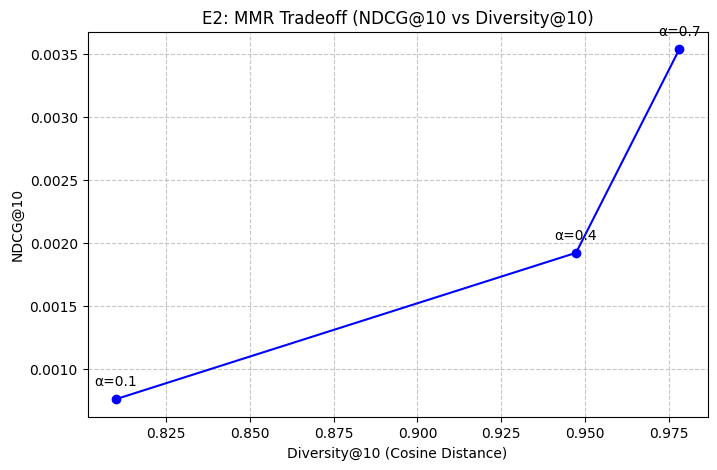

In [ ]:
# ==========================================
# PLOT E2: MMR TRADEOFF
# ==========================================

alphas_to_test = [0.1, 0.4, 0.7]
mmr_results = {"alpha": [], "ndcg": [], "diversity": []}

print("Generating data for Plot E2 (MMR Tradeoff on ALS model)...")

for a in alphas_to_test:
    avg_ndcg_a, avg_div_a = [], []

    for u_raw in eval_users:
        true_items = get_true_items(u_raw, test)
        if len(true_items) == 0: continue

        candidates = list(all_items - get_seen_movies(u_raw))
        top_m_als = rank_als(u_raw, candidates, mu, bu_als, bi_als, P_als, Q_als, user2idx, item2idx)[:CANDIDATE_POOL_SIZE]

        u_idx = user2idx[u_raw]
        base_scores = {c: float(mu + bu_als[u_idx] + bi_als[item2idx[c]] + P_als[u_idx] @ Q_als[item2idx[c]]) for c in top_m_als if c in item2idx}

        final_slate = mmr_rerank(top_m_als, base_scores, item_genres_normalized, K=SLATE_SIZE, alpha=a)

        avg_ndcg_a.append(ndcg_at_k(final_slate, true_items, SLATE_SIZE))
        avg_div_a.append(diversity_at_k(final_slate, item_genres_normalized, SLATE_SIZE))

    mmr_results["alpha"].append(a)
    mmr_results["ndcg"].append(np.mean(avg_ndcg_a))
    mmr_results["diversity"].append(np.mean(avg_div_a))


# --- Plotting ---
plt.figure(figsize=(8, 5))
plt.plot(mmr_results["diversity"], mmr_results["ndcg"], marker='o', linestyle='-', color='b')

for i, a in enumerate(alphas_to_test):
    plt.annotate(f'α={a}', (mmr_results["diversity"][i], mmr_results["ndcg"][i]),
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.title(f"E2: MMR Tradeoff (NDCG@{SLATE_SIZE} vs Diversity@{SLATE_SIZE})")
plt.xlabel(f"Diversity@{SLATE_SIZE} (Cosine Distance)")
plt.ylabel(f"NDCG@{SLATE_SIZE}")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 8. E3: Ablation
> "what changes when you remove MMR? when you remove popularity feature?" *(Section 4)*

Progress: 50/300 users evaluated.
Progress: 100/300 users evaluated.
Progress: 150/300 users evaluated.
Progress: 200/300 users evaluated.
Progress: 250/300 users evaluated.
Progress: 300/300 users evaluated.


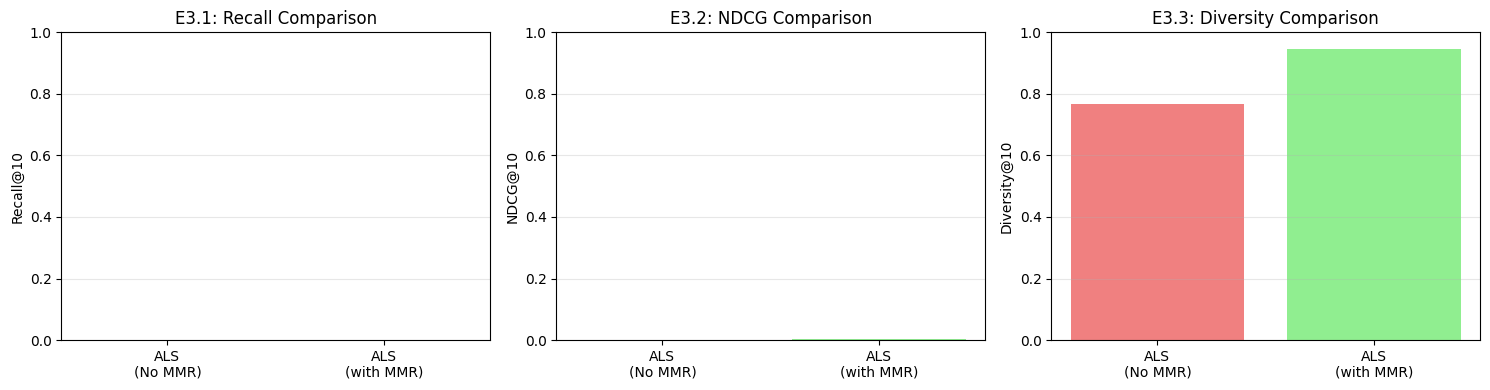


=== E3 ABLATION RESULTS (ALS without MMR) ===
Recall@10:    0.0012
NDCG@10:      0.0009
Diversity@10: 0.7679

=== E3 COMPARISON (ALS with MMR) ===
Recall@10:    0.0013
NDCG@10:      0.0019
Diversity@10: 0.9473


In [ ]:
# ==========================================
# ABLATION: ALS WITHOUT MMR
# ==========================================
als_no_mmr_results = {"recall": [], "ndcg": [], "diversity": []}
for idx, u_raw in enumerate(eval_users):
    if (idx + 1) % 50 == 0:
        print(f"Progress: {idx + 1}/{len(eval_users)} users evaluated.")

    true_items = get_true_items(u_raw, test)
    if len(true_items) == 0:
        continue

    candidates = list(all_items - get_seen_movies(u_raw))

    # Get top-K directly from ALS ranking (NO MMR reranking)
    top_als_raw = rank_als(u_raw, candidates, mu, bu_als, bi_als, P_als, Q_als, user2idx, item2idx)[:SLATE_SIZE]

    # Calculate metrics
    rec = recall_at_k(top_als_raw, true_items, SLATE_SIZE)
    ndcg = ndcg_at_k(top_als_raw, true_items, SLATE_SIZE)
    div = diversity_at_k(top_als_raw, item_genres_normalized, SLATE_SIZE)

    als_no_mmr_results["recall"].append(rec)
    als_no_mmr_results["ndcg"].append(ndcg)
    als_no_mmr_results["diversity"].append(div)
# Calculate averages
avg_recall_no_mmr = np.mean(als_no_mmr_results["recall"])
avg_ndcg_no_mmr = np.mean(als_no_mmr_results["ndcg"])
avg_div_no_mmr = np.mean(als_no_mmr_results["diversity"])

# --- Plotting: ALS with and without MMR comparison ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Recall@10
axes[0].bar(['ALS\n(No MMR)', 'ALS\n(with MMR)'],
            [avg_recall_no_mmr, np.mean(global_results["MF-ALS"]["recall"])],
            color=['lightcoral', 'lightgreen'])
axes[0].set_ylabel(f'Recall@{SLATE_SIZE}')
axes[0].set_title('E3.1: Recall Comparison')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: NDCG@10
axes[1].bar(['ALS\n(No MMR)', 'ALS\n(with MMR)'],
            [avg_ndcg_no_mmr, np.mean(global_results["MF-ALS"]["ndcg"])],
            color=['lightcoral', 'lightgreen'])
axes[1].set_ylabel(f'NDCG@{SLATE_SIZE}')
axes[1].set_title('E3.2: NDCG Comparison')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Diversity@10
axes[2].bar(['ALS\n(No MMR)', 'ALS\n(with MMR)'],
            [avg_div_no_mmr, np.mean(global_results["MF-ALS"]["diversity"])],
            color=['lightcoral', 'lightgreen'])
axes[2].set_ylabel(f'Diversity@{SLATE_SIZE}')
axes[2].set_title('E3.3: Diversity Comparison')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== E3 ABLATION RESULTS (ALS without MMR) ===")
print(f"Recall@{SLATE_SIZE}:    {avg_recall_no_mmr:.4f}")
print(f"NDCG@{SLATE_SIZE}:      {avg_ndcg_no_mmr:.4f}")
print(f"Diversity@{SLATE_SIZE}: {avg_div_no_mmr:.4f}")
print(f"\n=== E3 COMPARISON (ALS with MMR) ===")
print(f"Recall@{SLATE_SIZE}:    {np.mean(global_results['MF-ALS']['recall']):.4f}")
print(f"NDCG@{SLATE_SIZE}:      {np.mean(global_results['MF-ALS']['ndcg']):.4f}")
print(f"Diversity@{SLATE_SIZE}: {np.mean(global_results['MF-ALS']['diversity']):.4f}")

Progress: 50/300 users evaluated.
Progress: 100/300 users evaluated.
Progress: 150/300 users evaluated.
Progress: 200/300 users evaluated.
Progress: 250/300 users evaluated.
Progress: 300/300 users evaluated.


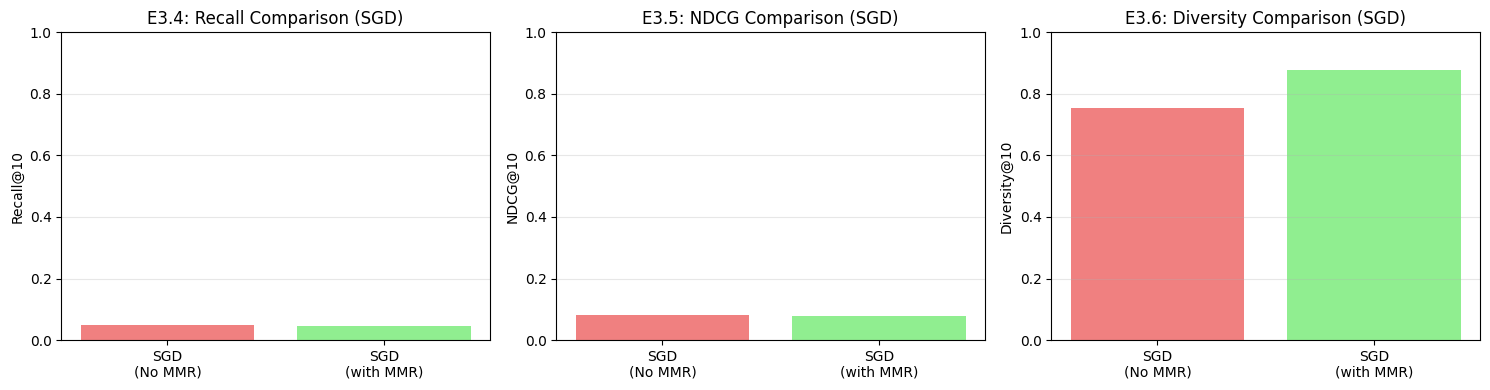


=== E3 ABLATION RESULTS (SGD without MMR) ===
Recall@10:    0.0505
NDCG@10:      0.0817
Diversity@10: 0.7534

=== E3 COMPARISON (SGD with MMR) ===
Recall@10:    0.0458
NDCG@10:      0.0795
Diversity@10: 0.8760


In [ ]:
# ==========================================
# ABLATION: SGD WITHOUT MMR
# ==========================================
sgd_no_mmr_results = {"recall": [], "ndcg": [], "diversity": []}
for idx, u_raw in enumerate(eval_users):
    if (idx + 1) % 50 == 0:
        print(f"Progress: {idx + 1}/{len(eval_users)} users evaluated.")

    true_items = get_true_items(u_raw, test)
    if len(true_items) == 0:
        continue

    candidates = list(all_items - get_seen_movies(u_raw))

    # Get top-K directly from SGD ranking (NO MMR reranking)
    top_sgd_raw = rank_sgd(u_raw, candidates, mu, bu, bi, P, Q, user2idx, item2idx)[:SLATE_SIZE]

    # Calculate metrics
    rec = recall_at_k(top_sgd_raw, true_items, SLATE_SIZE)
    ndcg = ndcg_at_k(top_sgd_raw, true_items, SLATE_SIZE)
    div = diversity_at_k(top_sgd_raw, item_genres_normalized, SLATE_SIZE)

    sgd_no_mmr_results["recall"].append(rec)
    sgd_no_mmr_results["ndcg"].append(ndcg)
    sgd_no_mmr_results["diversity"].append(div)

# Calculate averages
avg_recall_sgd_no_mmr = np.mean(sgd_no_mmr_results["recall"])
avg_ndcg_sgd_no_mmr = np.mean(sgd_no_mmr_results["ndcg"])
avg_div_sgd_no_mmr = np.mean(sgd_no_mmr_results["diversity"])

# --- Plotting: SGD with and without MMR comparison ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Recall@10
axes[0].bar(['SGD\n(No MMR)', 'SGD\n(with MMR)'],
            [avg_recall_sgd_no_mmr, np.mean(global_results["MF-SGD"]["recall"])],
            color=['lightcoral', 'lightgreen'])
axes[0].set_ylabel(f'Recall@{SLATE_SIZE}')
axes[0].set_title('E3.4: Recall Comparison (SGD)')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: NDCG@10
axes[1].bar(['SGD\n(No MMR)', 'SGD\n(with MMR)'],
            [avg_ndcg_sgd_no_mmr, np.mean(global_results["MF-SGD"]["ndcg"])],
            color=['lightcoral', 'lightgreen'])
axes[1].set_ylabel(f'NDCG@{SLATE_SIZE}')
axes[1].set_title('E3.5: NDCG Comparison (SGD)')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Diversity@10
axes[2].bar(['SGD\n(No MMR)', 'SGD\n(with MMR)'],
            [avg_div_sgd_no_mmr, np.mean(global_results["MF-SGD"]["diversity"])],
            color=['lightcoral', 'lightgreen'])
axes[2].set_ylabel(f'Diversity@{SLATE_SIZE}')
axes[2].set_title('E3.6: Diversity Comparison (SGD)')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== E3 ABLATION RESULTS (SGD without MMR) ===")
print(f"Recall@{SLATE_SIZE}:    {avg_recall_sgd_no_mmr:.4f}")
print(f"NDCG@{SLATE_SIZE}:      {avg_ndcg_sgd_no_mmr:.4f}")
print(f"Diversity@{SLATE_SIZE}: {avg_div_sgd_no_mmr:.4f}")
print(f"\n=== E3 COMPARISON (SGD with MMR) ===")
print(f"Recall@{SLATE_SIZE}:    {np.mean(global_results['MF-SGD']['recall']):.4f}")
print(f"NDCG@{SLATE_SIZE}:      {np.mean(global_results['MF-SGD']['ndcg']):.4f}")
print(f"Diversity@{SLATE_SIZE}: {np.mean(global_results['MF-SGD']['diversity']):.4f}")